In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Check GPU availability

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU is available!")
    print(gpus)
else:
    print("GPU is not available.")

GPU is available!
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [2]:
import zipfile
import os

zip_file = "/content/archive (1).zip"
extract_path = "/content/covid_dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
import os

for root, dirs, files in os.walk("/content/covid_dataset"):
    level = root.replace("/content/covid_dataset", "").count(os.sep)
    indent = "    " * level
    print(indent + os.path.basename(root) + "/")

    for file in files[:5]:
        print(indent + "    " + file)

covid_dataset/
    COVID-19_Radiography_Dataset/
        Normal.metadata.xlsx
        Viral Pneumonia.metadata.xlsx
        README.md.txt
        COVID.metadata.xlsx
        Lung_Opacity.metadata.xlsx
        Normal/
            masks/
                Normal-7922.png
                Normal-2632.png
                Normal-6866.png
                Normal-4265.png
                Normal-8091.png
            images/
                Normal-7922.png
                Normal-2632.png
                Normal-6866.png
                Normal-4265.png
                Normal-8091.png
        Lung_Opacity/
            masks/
                Lung_Opacity-2839.png
                Lung_Opacity-5245.png
                Lung_Opacity-258.png
                Lung_Opacity-4670.png
                Lung_Opacity-3043.png
            images/
                Lung_Opacity-2839.png
                Lung_Opacity-5245.png
                Lung_Opacity-258.png
                Lung_Opacity-4670.png
                Lung_Op

In [4]:
import os

print(os.listdir("/content/covid_dataset"))

['COVID-19_Radiography_Dataset']


In [5]:
import os

for root, dirs, files in os.walk("/content/covid_dataset"):
    print(root)

/content/covid_dataset
/content/covid_dataset/COVID-19_Radiography_Dataset
/content/covid_dataset/COVID-19_Radiography_Dataset/Normal
/content/covid_dataset/COVID-19_Radiography_Dataset/Normal/masks
/content/covid_dataset/COVID-19_Radiography_Dataset/Normal/images
/content/covid_dataset/COVID-19_Radiography_Dataset/Lung_Opacity
/content/covid_dataset/COVID-19_Radiography_Dataset/Lung_Opacity/masks
/content/covid_dataset/COVID-19_Radiography_Dataset/Lung_Opacity/images
/content/covid_dataset/COVID-19_Radiography_Dataset/COVID
/content/covid_dataset/COVID-19_Radiography_Dataset/COVID/masks
/content/covid_dataset/COVID-19_Radiography_Dataset/COVID/images
/content/covid_dataset/COVID-19_Radiography_Dataset/Viral Pneumonia
/content/covid_dataset/COVID-19_Radiography_Dataset/Viral Pneumonia/masks
/content/covid_dataset/COVID-19_Radiography_Dataset/Viral Pneumonia/images


In [6]:
import os

image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

for root, dirs, files in os.walk("/content/covid_dataset"):
    image_count = sum(
        1 for f in files
        if f.lower().endswith(image_extensions)
    )

    if image_count > 0:
        print(root, "→", image_count, "images")

/content/covid_dataset/COVID-19_Radiography_Dataset/Normal/masks → 10192 images
/content/covid_dataset/COVID-19_Radiography_Dataset/Normal/images → 10192 images
/content/covid_dataset/COVID-19_Radiography_Dataset/Lung_Opacity/masks → 6012 images
/content/covid_dataset/COVID-19_Radiography_Dataset/Lung_Opacity/images → 6012 images
/content/covid_dataset/COVID-19_Radiography_Dataset/COVID/masks → 3616 images
/content/covid_dataset/COVID-19_Radiography_Dataset/COVID/images → 3616 images
/content/covid_dataset/COVID-19_Radiography_Dataset/Viral Pneumonia/masks → 1345 images
/content/covid_dataset/COVID-19_Radiography_Dataset/Viral Pneumonia/images → 1345 images


In [7]:
import os

dataset_path = "/content/covid_dataset"

print("Dataset path:", dataset_path)
print("Folders:", os.listdir(dataset_path))

Dataset path: /content/covid_dataset
Folders: ['COVID-19_Radiography_Dataset']


In [8]:
classes = []

for item in os.listdir(dataset_path):
    path = os.path.join(dataset_path, item)

    if os.path.isdir(path):
        classes.append(item)

print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['COVID-19_Radiography_Dataset']
Number of classes: 1


In [9]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

class_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    count = sum(
        1 for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    )

    class_counts[cls] = count

print("Image count for each class:")
print(class_counts)

Image count for each class:
{'COVID-19_Radiography_Dataset': 0}


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
eda_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number of Images"]
)

eda_df

,Class,Number of Images
0,COVID-19_Radiography_Dataset,0


In [16]:
import os

dataset_path = "/content/covid_dataset/COVID-19_Radiography_Dataset"

print("Folders inside dataset:")
print(os.listdir(dataset_path))

Folders inside dataset:
['Normal', 'Normal.metadata.xlsx', 'Viral Pneumonia.metadata.xlsx', 'Lung_Opacity', 'README.md.txt', 'COVID', 'COVID.metadata.xlsx', 'Lung_Opacity.metadata.xlsx', 'Viral Pneumonia']


In [17]:
classes = [
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
]

print("Classes:", classes)

Classes: ['Normal', 'Lung_Opacity', 'COVID', 'Viral Pneumonia']


In [18]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

class_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    count = 0

    for root, dirs, files in os.walk(class_path):
        count += sum(
            1 for file in files
            if file.lower().endswith(image_extensions)
        )

    class_counts[cls] = count

print("Image counts:")
print(class_counts)

Image counts:
{'Normal': 20384, 'Lung_Opacity': 12024, 'COVID': 7232, 'Viral Pneumonia': 2690}


In [20]:
dataset_path = "/content/covid_dataset/COVID-19_Radiography_Dataset"

print(os.listdir(dataset_path))

['Normal', 'Normal.metadata.xlsx', 'Viral Pneumonia.metadata.xlsx', 'Lung_Opacity', 'README.md.txt', 'COVID', 'COVID.metadata.xlsx', 'Lung_Opacity.metadata.xlsx', 'Viral Pneumonia']


In [21]:
classes = [
    "COVID",
    "Normal",
    "Lung_Opacity",
    "Viral Pneumonia"
]

print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['COVID', 'Normal', 'Lung_Opacity', 'Viral Pneumonia']
Number of classes: 4


In [22]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

class_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    count = 0

    for root, dirs, files in os.walk(class_path):
        count += sum(
            1 for file in files
            if file.lower().endswith(image_extensions)
        )

    class_counts[cls] = count

print("Image counts:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

Image counts:
COVID: 7232
Normal: 20384
Lung_Opacity: 12024
Viral Pneumonia: 2690


In [23]:
eda_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number of Images"]
)

eda_df

,Class,Number of Images
0,COVID,7232
1,Normal,20384
2,Lung_Opacity,12024
3,Viral Pneumonia,2690


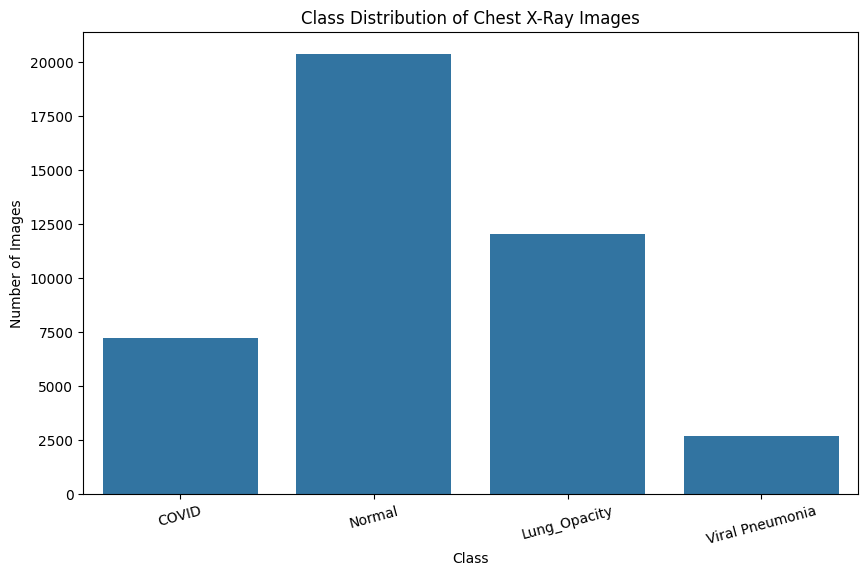

In [24]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=eda_df,
    x="Class",
    y="Number of Images"
)

plt.title("Class Distribution of Chest X-Ray Images")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=15)
plt.show()

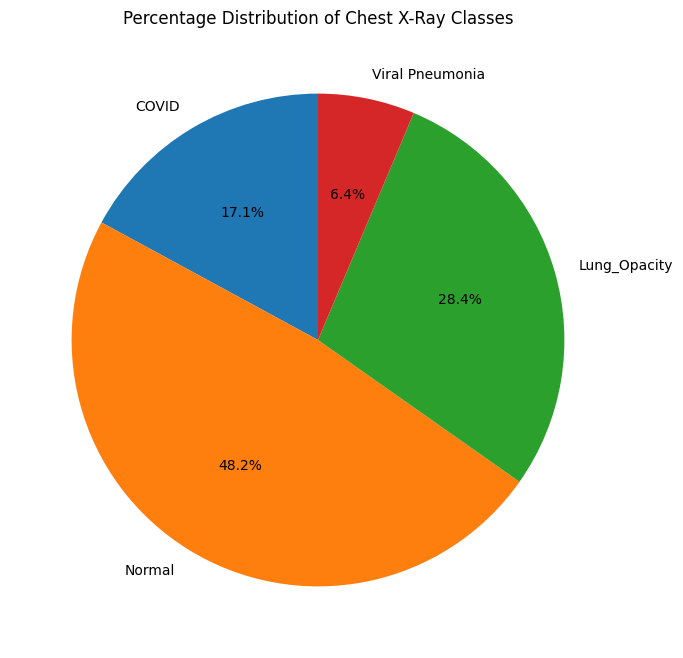

In [25]:
plt.figure(figsize=(8, 8))

plt.pie(
    eda_df["Number of Images"],
    labels=eda_df["Class"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage Distribution of Chest X-Ray Classes")
plt.show()

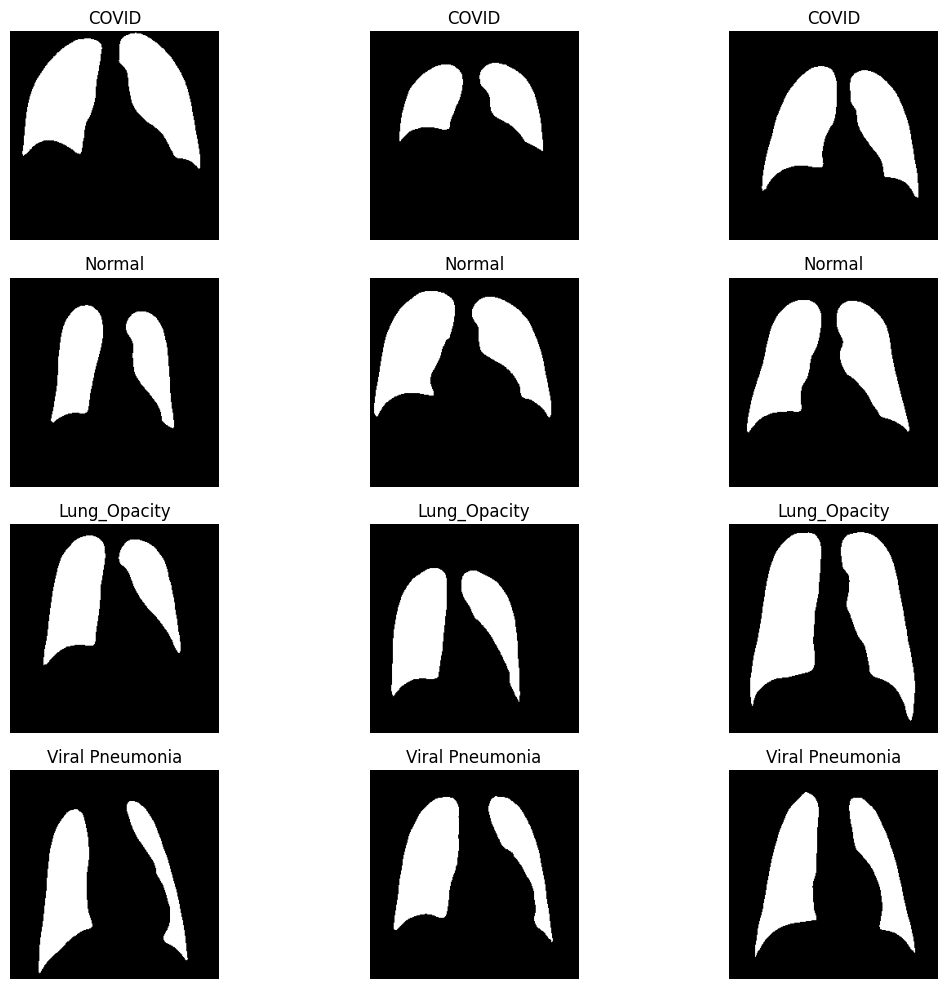

In [29]:
from PIL import Image
import os
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

plot_index = 1

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    image_paths = []

    for root, dirs, files in os.walk(class_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                image_paths.append(os.path.join(root, file))

    for image_path in image_paths[:3]:

        img = Image.open(image_path)

        plt.subplot(len(classes), 3, plot_index)
        plt.imshow(img, cmap="gray")
        plt.title(cls)
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()


In [30]:
image_dimensions = []

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    for root, dirs, files in os.walk(class_path):

        for file in files:

            if file.lower().endswith(image_extensions):

                image_path = os.path.join(root, file)

                try:
                    img = Image.open(image_path)

                    width, height = img.size

                    image_dimensions.append({
                        "Class": cls,
                        "Width": width,
                        "Height": height
                    })

                except:
                    pass

dimensions_df = pd.DataFrame(image_dimensions)

print("Total images analyzed:", len(dimensions_df))

dimensions_df.head()

Total images analyzed: 42330


,Class,Width,Height
0,COVID,256,256
1,COVID,256,256
2,COVID,256,256
3,COVID,256,256
4,COVID,256,256


In [31]:
image_modes = []

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    for root, dirs, files in os.walk(class_path):

        for file in files:

            if file.lower().endswith(image_extensions):

                image_path = os.path.join(root, file)

                try:
                    img = Image.open(image_path)

                    image_modes.append({
                        "Class": cls,
                        "Mode": img.mode
                    })

                except:
                    pass

modes_df = pd.DataFrame(image_modes)

print("Image modes found:")
print(modes_df["Mode"].value_counts())

modes_df.head()

Image modes found:
Mode
RGB    21305
L      21025
Name: count, dtype: int64


,Class,Mode
0,COVID,RGB
1,COVID,RGB
2,COVID,RGB
3,COVID,RGB
4,COVID,RGB


In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image

dataset_path = "/content/covid_dataset/COVID-19_Radiography_Dataset"

classes = [
    "COVID",
    "Normal",
    "Lung_Opacity",
    "Viral Pneumonia"
]

image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

print("Setup completed!")
print("Classes:", classes)

Setup completed!
Classes: ['COVID', 'Normal', 'Lung_Opacity', 'Viral Pneumonia']


In [1]:
import os

print(os.path.exists("/content/covid_dataset"))
print(os.path.exists("/content/covid_dataset/COVID-19_Radiography_Dataset"))

print(os.listdir("/content"))

True
True
['.config', 'covid_dataset', 'archive (1).zip', 'sample_data']


In [1]:
import os
import numpy as np
from PIL import Image

dataset_path = "/content/covid_dataset/COVID-19_Radiography_Dataset"

classes = [
    "COVID",
    "Normal",
    "Lung_Opacity",
    "Viral Pneumonia"
]

image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

# Collect only a small number of images
sample_images = []

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    for root, dirs, files in os.walk(class_path):

        for file in files:

            if file.lower().endswith(image_extensions):

                sample_images.append(
                    (cls, os.path.join(root, file))
                )

# Use only 100 images for pixel analysis
sample_images = sample_images[:100]

pixel_values = []

for cls, image_path in sample_images:

    try:
        img = Image.open(image_path).convert("L")

        # Resize before collecting pixels to reduce memory
        img = img.resize((64, 64))

        pixels = np.array(img)

        pixel_values.extend(pixels.flatten())

    except:
        continue

pixel_values = np.array(pixel_values)

print("Images analyzed:", len(sample_images))
print("Total pixels analyzed:", len(pixel_values))
print("Minimum pixel value:", pixel_values.min())
print("Maximum pixel value:", pixel_values.max())
print("Mean pixel value:", round(pixel_values.mean(), 2))
print("Standard deviation:", round(pixel_values.std(), 2))

Images analyzed: 100
Total pixels analyzed: 409600
Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 62.0
Standard deviation: 106.52


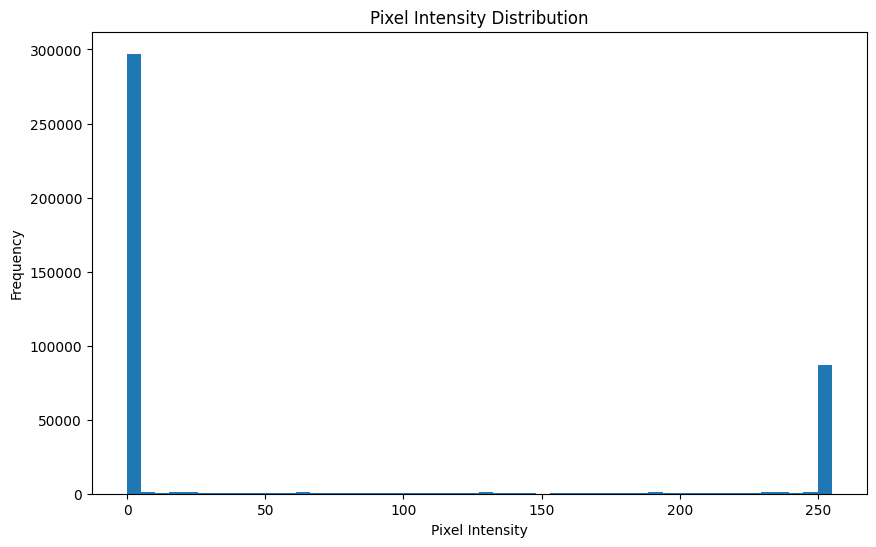

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    pixel_values,
    bins=50
)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

In [3]:
import os
import random
import shutil

dataset_path = "/content/covid_dataset/COVID-19_Radiography_Dataset"

classes = [
    "COVID",
    "Normal",
    "Lung_Opacity",
    "Viral Pneumonia"
]

image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

# Output folders
split_path = "/content/covid_split"

train_path = os.path.join(split_path, "train")
val_path = os.path.join(split_path, "validation")
test_path = os.path.join(split_path, "test")

# Create folders
for path in [train_path, val_path, test_path]:
    for cls in classes:
        os.makedirs(os.path.join(path, cls), exist_ok=True)

print("Train, validation and test folders created!")

Train, validation and test folders created!


In [4]:
import os
import random
import shutil

random.seed(42)

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    # Collect image paths
    image_paths = []

    for root, dirs, files in os.walk(class_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                image_paths.append(os.path.join(root, file))

    # Shuffle images
    random.shuffle(image_paths)

    # Calculate split sizes
    total = len(image_paths)
    train_end = int(0.80 * total)
    val_end = int(0.90 * total)

    train_images = image_paths[:train_end]
    val_images = image_paths[train_end:val_end]
    test_images = image_paths[val_end:]

    # Copy images
    for i, image_path in enumerate(train_images):
        destination = os.path.join(
            train_path, cls, f"{cls}_train_{i}.jpg"
        )
        shutil.copy2(image_path, destination)

    for i, image_path in enumerate(val_images):
        destination = os.path.join(
            val_path, cls, f"{cls}_val_{i}.jpg"
        )
        shutil.copy2(image_path, destination)

    for i, image_path in enumerate(test_images):
        destination = os.path.join(
            test_path, cls, f"{cls}_test_{i}.jpg"
        )
        shutil.copy2(image_path, destination)

    print(
        cls,
        "→ Train:", len(train_images),
        "| Validation:", len(val_images),
        "| Test:", len(test_images)
    )

print("\nDataset splitting completed!")

COVID → Train: 5785 | Validation: 723 | Test: 724
Normal → Train: 16307 | Validation: 2038 | Test: 2039
Lung_Opacity → Train: 9619 | Validation: 1202 | Test: 1203
Viral Pneumonia → Train: 2152 | Validation: 269 | Test: 269

Dataset splitting completed!


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image size
IMG_SIZE = (224, 224)

# Batch size
BATCH_SIZE = 32

# Training preprocessing + augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True
)

# Validation and test preprocessing
test_datagen = ImageDataGenerator(
    rescale=1./255
)

# Training generator
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

# Validation generator
validation_generator = test_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# Test generator
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("\nImage preprocessing completed!")

Found 33863 images belonging to 4 classes.
Found 4232 images belonging to 4 classes.
Found 4235 images belonging to 4 classes.

Image preprocessing completed!


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

cnn_model = models.Sequential([

    # Input + first convolution block
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Third convolution block
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Classification layers
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # 4 classes
    layers.Dense(4, activation="softmax")
])

cnn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully!")

CNN model compiled successfully!


In [9]:
cnn_history = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)


Epoch 1/5
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 453s 428ms/step - accuracy: 0.6823 - loss: 0.7816 - val_accuracy: 0.7450 - val_loss: 0.6252
Epoch 2/5
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 447s 422ms/step - accuracy: 0.6907 - loss: 0.7607 - val_accuracy: 0.7481 - val_loss: 0.6234
Epoch 3/5
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 450s 425ms/step - accuracy: 0.6983 - loss: 0.7415 - val_accuracy: 0.7398 - val_loss: 0.6451
Epoch 4/5
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 445s 420ms/step - accuracy: 0.7063 - loss: 0.7311 - val_accuracy: 0.7625 - val_loss: 0.5911
Epoch 5/5
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 445s 420ms/step - accuracy: 0.7112 - loss: 0.7212 - val_accuracy: 0.7500 - val_loss: 0.6399


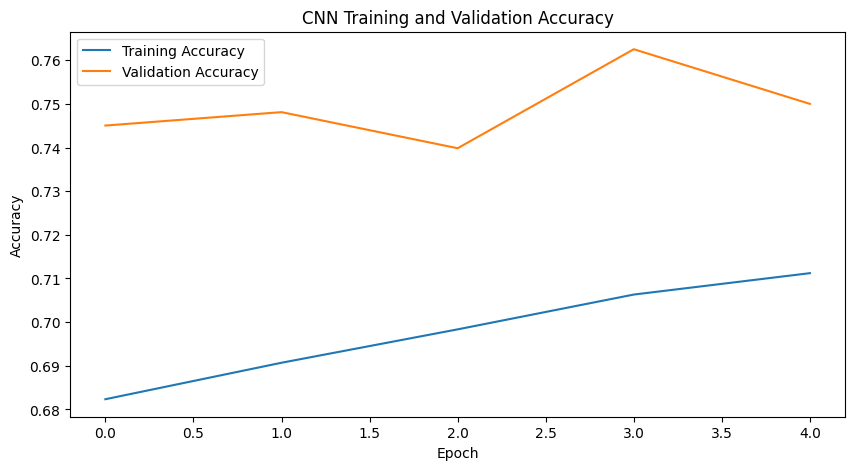

In [10]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(10, 5))

plt.plot(cnn_history.history["accuracy"], label="Training Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

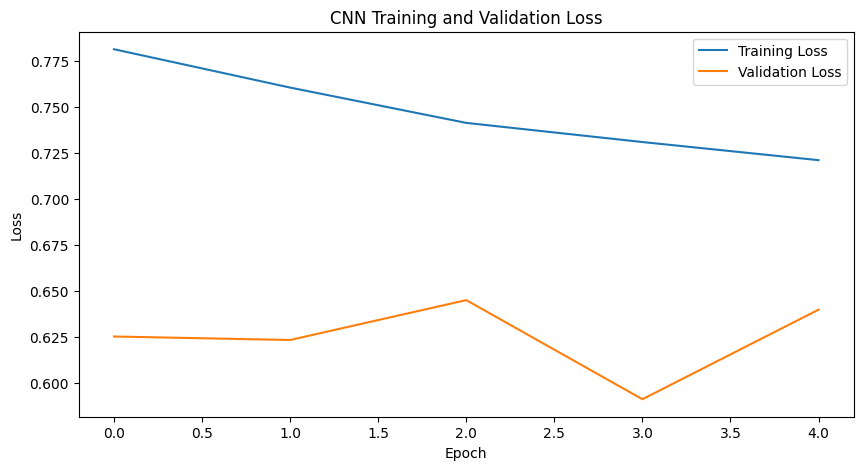

In [11]:
# Loss graph
plt.figure(figsize=(10, 5))

plt.plot(cnn_history.history["loss"], label="Training Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [12]:
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(
    test_generator
)

print("CNN Test Accuracy:", round(cnn_test_accuracy * 100, 2), "%")
print("CNN Test Loss:", round(cnn_test_loss, 4))

133/133 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.7429 - loss: 0.6498
CNN Test Accuracy: 74.29 %
CNN Test Loss: 0.6498


133/133 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step
CNN Classification Report:

                 precision    recall  f1-score   support

          COVID       0.83      0.39      0.53       724
   Lung_Opacity       0.77      0.65      0.70      1203
         Normal       0.71      0.95      0.81      2039
Viral Pneumonia       0.93      0.55      0.69       269

       accuracy                           0.74      4235
      macro avg       0.81      0.64      0.69      4235
   weighted avg       0.76      0.74      0.73      4235



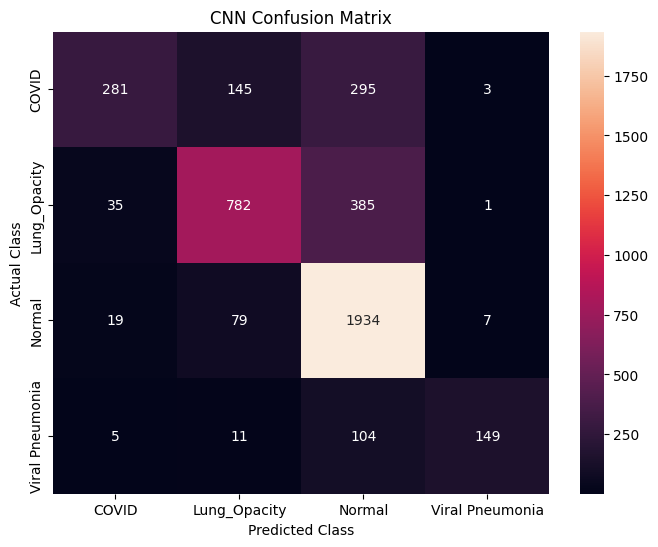

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reset test generator
test_generator.reset()

# Get predictions
predictions = cnn_model.predict(test_generator)

# Convert probabilities to class labels
y_pred = np.argmax(predictions, axis=1)

# Actual labels
y_true = test_generator.classes

# Class names
class_names = list(test_generator.class_indices.keys())

# Classification report
print("CNN Classification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [14]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

# Load pretrained VGG16
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

print("VGG16 loaded successfully!")
print("Number of layers:", len(base_model.layers))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
VGG16 loaded successfully!
Number of layers: 19


In [15]:
vgg16_model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    # 4 output classes
    layers.Dense(4, activation="softmax")
])

vgg16_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 66,180 (258.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [16]:
vgg16_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("VGG16 model compiled successfully!")

VGG16 model compiled successfully!


In [17]:
vgg16_history = vgg16_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

Epoch 1/5
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 553s 505ms/step - accuracy: 0.6141 - loss: 0.9452 - val_accuracy: 0.6928 - val_loss: 0.7537
Epoch 2/5
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 523s 494ms/step - accuracy: 0.6805 - loss: 0.7952 - val_accuracy: 0.7216 - val_loss: 0.6841
Epoch 3/5
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 524s 495ms/step - accuracy: 0.7019 - loss: 0.7519 - val_accuracy: 0.7302 - val_loss: 0.6713
Epoch 4/5
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 517s 488ms/step - accuracy: 0.7160 - loss: 0.7204 - val_accuracy: 0.7507 - val_loss: 0.6295
Epoch 5/5
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 518s 489ms/step - accuracy: 0.7249 - loss: 0.6986 - val_accuracy: 0.7545 - val_loss: 0.6137


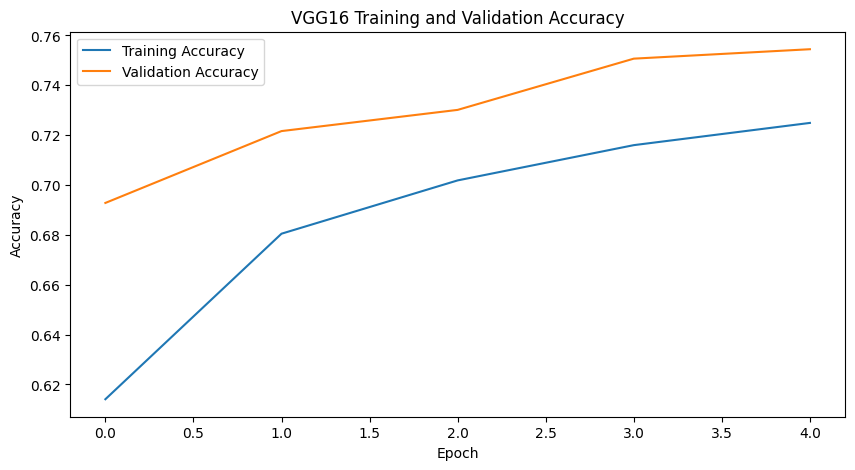

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    vgg16_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    vgg16_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("VGG16 Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

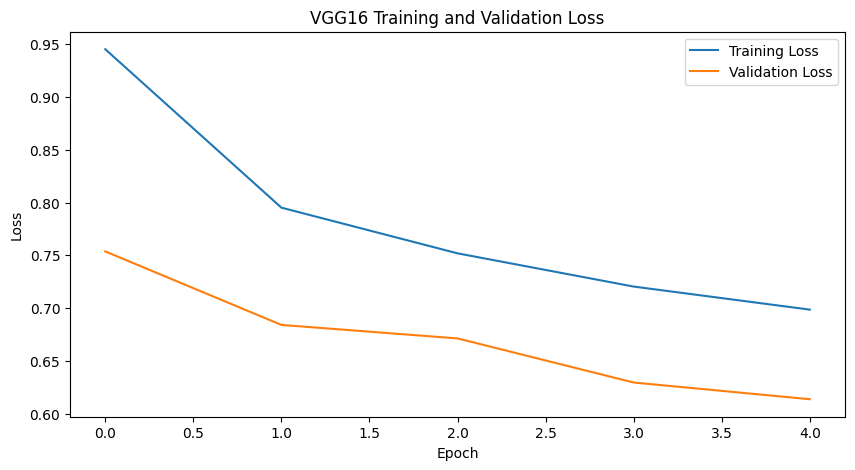

In [19]:
plt.figure(figsize=(10,5))

plt.plot(
    vgg16_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    vgg16_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("VGG16 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [20]:
vgg16_test_loss, vgg16_test_accuracy = vgg16_model.evaluate(test_generator)

print("VGG16 Test Accuracy:", round(vgg16_test_accuracy * 100, 2), "%")
print("VGG16 Test Loss:", round(vgg16_test_loss, 4))

133/133 ━━━━━━━━━━━━━━━━━━━━ 35s 259ms/step - accuracy: 0.7466 - loss: 0.6298
VGG16 Test Accuracy: 74.66 %
VGG16 Test Loss: 0.6298


133/133 ━━━━━━━━━━━━━━━━━━━━ 27s 197ms/step
VGG16 Classification Report:

                 precision    recall  f1-score   support

          COVID       0.87      0.30      0.44       724
   Lung_Opacity       0.65      0.82      0.73      1203
         Normal       0.79      0.85      0.82      2039
Viral Pneumonia       0.82      0.83      0.82       269

       accuracy                           0.75      4235
      macro avg       0.78      0.70      0.70      4235
   weighted avg       0.77      0.75      0.73      4235



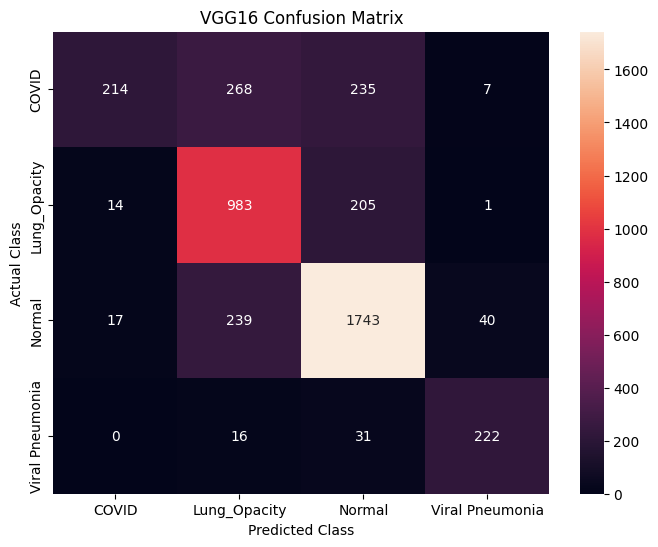

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reset test generator
test_generator.reset()

# Get predictions
predictions = vgg16_model.predict(test_generator)

# Convert probabilities to class numbers
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# Get class names
class_names = list(test_generator.class_indices.keys())

# Classification Report
print("VGG16 Classification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("VGG16 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

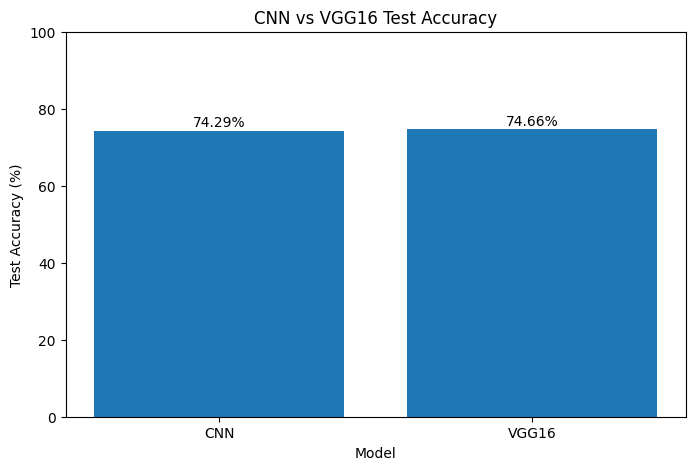

CNN Test Accuracy: 74.29 %
VGG16 Test Accuracy: 74.66 %


In [22]:
import matplotlib.pyplot as plt

models_name = ["CNN", "VGG16"]
accuracies = [
    cnn_test_accuracy * 100,
    vgg16_test_accuracy * 100
]

plt.figure(figsize=(8,5))

plt.bar(models_name, accuracies)

plt.title("CNN vs VGG16 Test Accuracy")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")

for i, accuracy in enumerate(accuracies):
    plt.text(
        i,
        accuracy + 1,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.ylim(0, 100)
plt.show()

print("CNN Test Accuracy:", round(cnn_test_accuracy * 100, 2), "%")
print("VGG16 Test Accuracy:", round(vgg16_test_accuracy * 100, 2), "%")

Saving covid.jpeg to covid.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


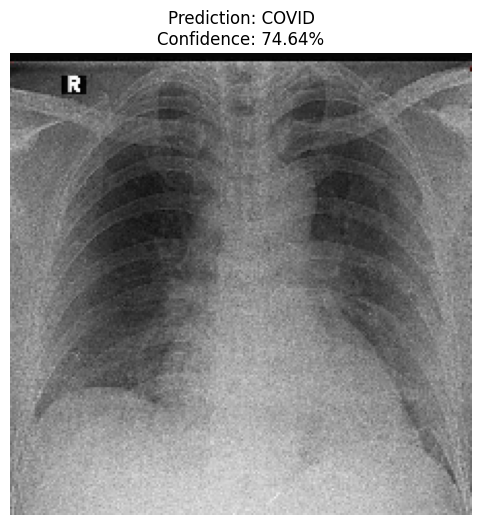

Predicted Class: COVID
Confidence: 74.64 %


In [23]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Upload an X-ray image
uploaded = files.upload()

# Get uploaded image path
image_path = list(uploaded.keys())[0]

# Load and resize image
img = image.load_img(
    image_path,
    target_size=(224, 224)
)

# Convert image to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = vgg16_model.predict(img_array)

# Get predicted class
predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

# Display image
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.axis("off")
plt.show()

print("Predicted Class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


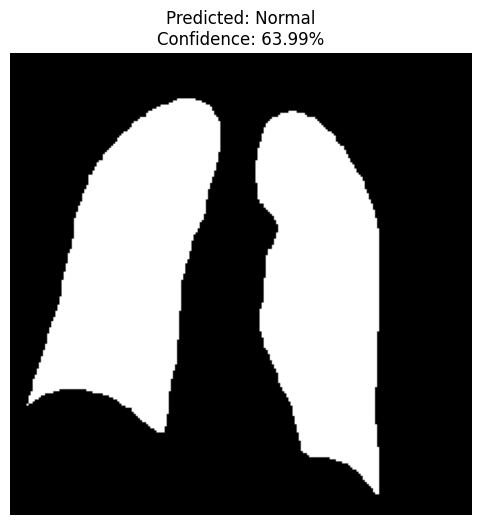

Actual Class: COVID
Predicted Class: Normal
Confidence: 63.99 %


In [24]:
import os
import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

# Find COVID images from your existing dataset
covid_path = os.path.join(dataset_path, "COVID")

covid_images = []

for root, dirs, files in os.walk(covid_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            covid_images.append(os.path.join(root, file))

# Select one random COVID X-ray
image_path = random.choice(covid_images)

# Load image
img = image.load_img(
    image_path,
    target_size=(224, 224)
)

# Convert to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = vgg16_model.predict(img_array)

predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

# Display
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(
    f"Predicted: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.axis("off")
plt.show()

print("Actual Class: COVID")
print("Predicted Class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

In [25]:
# Save the trained VGG16 model

vgg16_model.save("/content/COVID_VGG16_Model.keras")

print("VGG16 model saved successfully!")

VGG16 model saved successfully!


In [26]:
# Final model comparison

print("========== FINAL RESULTS ==========")

print("\nCNN")
print("Test Accuracy:", round(cnn_test_accuracy * 100, 2), "%")
print("Test Loss:", round(cnn_test_loss, 4))

print("\nVGG16")
print("Test Accuracy:", round(vgg16_test_accuracy * 100, 2), "%")
print("Test Loss:", round(vgg16_test_loss, 4))

# Determine the better model
if vgg16_test_accuracy > cnn_test_accuracy:
    print("\nBetter Model: VGG16")
else:
    print("\nBetter Model: CNN")

========== FINAL RESULTS ==========

CNN
Test Accuracy: 74.29 %
Test Loss: 0.6498

VGG16
Test Accuracy: 74.66 %
Test Loss: 0.6298

Better Model: VGG16
